# Stationary incompressible Navier--Stokes PINN

This notebook performs the **six stationary incompressible Navier--Stokes PINN comparisons considered in the accompanying paper**:

1. **MSE**
2. **Inverse-Dirichlet adaptive weighting**
3. **GradNorm**
4. **NTK-based balancing**
5. **SINOS**
6. **D-SINOS**

The experiment can either be started from scratch or resumed from saved states:

```python
MODE = "fresh"   # start a new experiment
MODE = "resume"  # continue from warm_start_states/
```


In [88]:
import copy
import os
import time

CPU_COUNT = os.cpu_count() or 1
MAX_METHOD_WORKERS = 2
N_METHOD_WORKERS = min(MAX_METHOD_WORKERS, CPU_COUNT)
THREADS_PER_WORKER = max(1, CPU_COUNT // N_METHOD_WORKERS)

os.environ["OMP_NUM_THREADS"] = str(THREADS_PER_WORKER)
os.environ["MKL_NUM_THREADS"] = str(THREADS_PER_WORKER)
os.environ["OPENBLAS_NUM_THREADS"] = str(THREADS_PER_WORKER)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(THREADS_PER_WORKER)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from joblib import Parallel, delayed, parallel_config
from pathlib import Path
from matplotlib.colors import LogNorm

from dd_discretization import DomainDecompositionDiscretization
from utils import make_boundary_hhalf_matrix_torch


In [89]:
# --- Experiment configuration ---

MODE = "resume"  # "fresh" or "resume"
CELLWISE_NEGATIVE_NORM = True
RESULT_DIR = Path("results/navier_stokes_pinn_balancing")
WARM_START_DIR = RESULT_DIR / "warm_start_states"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
WARM_START_DIR.mkdir(parents=True, exist_ok=True)

SEED = 1234
N_REPS = 1
REP_SEEDS = [SEED]

if MODE == "resume":
    manifest_path = WARM_START_DIR / "manifest.pt"

    if manifest_path.exists():
        manifest = torch.load(
            manifest_path,
            map_location="cpu",
            weights_only=False,
        )

        if manifest.get("REP_SEEDS"):
            SEED = int(manifest["REP_SEEDS"][0])
            REP_SEEDS = [SEED]

elif MODE != "fresh":
    raise ValueError("MODE must be either 'fresh' or 'resume'.")

device = torch.device("cpu")
dtype = torch.float64
torch.set_default_dtype(dtype)

np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_num_threads(THREADS_PER_WORKER)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print("MODE:", MODE)
print("RESULT_DIR:", RESULT_DIR)
print("WARM_START_DIR:", WARM_START_DIR)
print("N_REPS:", N_REPS)
print("seeds:", REP_SEEDS)
print("device:", device)
print("dtype:", dtype)
print("parallel method workers:", N_METHOD_WORKERS)
print("CPU threads per worker:", THREADS_PER_WORKER)


MODE: resume
RESULT_DIR: results/navier_stokes_pinn_balancing
WARM_START_DIR: results/navier_stokes_pinn_balancing/warm_start_states
N_REPS: 1
seeds: [1234]
device: cpu
dtype: torch.float64
parallel method workers: 2
CPU threads per worker: 6


## Problem

### Stationary incompressible Navier--Stokes equations

On $\Omega=(-1,1)^2$, we consider
$$
-\nu\Delta \boldsymbol{u}
+
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u}
+
\nabla p
=
\boldsymbol{f},
\qquad
\nabla\cdot\boldsymbol{u}=0
\quad\text{in }\Omega,
$$
with Dirichlet data
$$
\boldsymbol{u}=\boldsymbol{g}
\quad\text{on }\partial\Omega,
$$
and pressure normalization
$$
\int_\Omega p\,dx=0.
$$

We use $\nu=0.05$ and the manufactured divergence-free velocity generated by
$$
\psi(x,y)=\sin(\pi x)\sin(\pi y),
\qquad
\boldsymbol{u}^*
=
\left(
\partial_y\psi,
-\partial_x\psi
\right),
$$
together with
$$
p^*(x,y)
=
0.5\sin(2\pi x+\pi y).
$$

The boundary data are given by the trace of $\boldsymbol{u}^*$, and the forcing is obtained analytically from
$$
\boldsymbol{f}
=
-\nu\Delta\boldsymbol{u}^*
+
(\boldsymbol{u}^*\cdot\nabla)\boldsymbol{u}^*
+
\nabla p^*.
$$


In [90]:
NU = 0.05
VEL_AMP = 1.0
P_AMP = 0.5


def exact_fields(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    pi = torch.as_tensor(np.pi, device=x.device, dtype=x.dtype)

    u1 = VEL_AMP * pi * torch.sin(pi * x1) * torch.cos(pi * x2)
    u2 = -VEL_AMP * pi * torch.cos(pi * x1) * torch.sin(pi * x2)
    p = P_AMP * torch.sin(2.0 * pi * x1 + pi * x2)

    return torch.cat([u1, u2], dim=1), p


def first_derivatives(s, x):
    return torch.autograd.grad(
        s,
        x,
        grad_outputs=torch.ones_like(s),
        create_graph=True,
        retain_graph=True,
    )[0]


def laplacian_scalar(s, x):
    grad_s = first_derivatives(s, x)

    s_x = grad_s[:, 0:1]
    s_y = grad_s[:, 1:2]

    s_xx = torch.autograd.grad(
        s_x,
        x,
        grad_outputs=torch.ones_like(s_x),
        create_graph=True,
        retain_graph=True,
    )[0][:, 0:1]

    s_yy = torch.autograd.grad(
        s_y,
        x,
        grad_outputs=torch.ones_like(s_y),
        create_graph=True,
        retain_graph=True,
    )[0][:, 1:2]

    return s_xx + s_yy


def rhs_f(x):
    x_req = x.detach().clone().requires_grad_(True)

    u, p = exact_fields(x_req)
    u1 = u[:, 0:1]
    u2 = u[:, 1:2]

    grad_u1 = first_derivatives(u1, x_req)
    grad_u2 = first_derivatives(u2, x_req)
    grad_p = first_derivatives(p, x_req)

    u1_x = grad_u1[:, 0:1]
    u1_y = grad_u1[:, 1:2]
    u2_x = grad_u2[:, 0:1]
    u2_y = grad_u2[:, 1:2]

    lap_u1 = laplacian_scalar(u1, x_req)
    lap_u2 = laplacian_scalar(u2, x_req)

    conv1 = u1 * u1_x + u2 * u1_y
    conv2 = u1 * u2_x + u2 * u2_y

    f1 = -NU * lap_u1 + conv1 + grad_p[:, 0:1]
    f2 = -NU * lap_u2 + conv2 + grad_p[:, 1:2]

    return torch.cat([f1, f2], dim=1).detach()


In [91]:
# --- Discretization ---

# Polynomial degrees for the Gauss-Legendre tensor grid
nx, ny = 10, 10

# Number of cells in x/y direction
rx, ry = 8, 8

disc = DomainDecompositionDiscretization(
    polynomial_degrees=(nx, ny),
    cells_per_dim=(rx, ry),
    domain=[(-1.0, 1.0), (-1.0, 1.0)],
)
disc.init_boundary_quadrature()

pde_points = disc.points
assert pde_points.shape == (disc.N, 2)

X_pde = torch.as_tensor(pde_points, device=device, dtype=dtype)
X_bc = torch.as_tensor(disc.X_bc, device=device, dtype=dtype)
u_bc, _ = exact_fields(X_bc)
u_bc = u_bc.detach()
f_pde = rhs_f(X_pde).detach()

W_bc = torch.as_tensor(disc.W_bc, device=device, dtype=dtype)
W = torch.as_tensor(disc.W, device=device, dtype=dtype)
Hmat_pinv = torch.as_tensor(disc.Hmat_pinv, device=device, dtype=dtype)
Hmat_pinv_s = torch.as_tensor(disc.Hmat_s_pinv, device=device, dtype=dtype)

W_bc_half = make_boundary_hhalf_matrix_torch(
    X_bc,
    W_bc,
    boundary_dim=1,
).to(device=device, dtype=dtype)

N_CELLS = rx * ry
N_LOCAL = (nx + 1) * (ny + 1)
assert disc.N == N_CELLS * N_LOCAL

if CELLWISE_NEGATIVE_NORM:
    Q_sinos = torch.stack([
        W[cell * N_LOCAL:(cell + 1) * N_LOCAL,
          cell * N_LOCAL:(cell + 1) * N_LOCAL]
        @ Hmat_pinv[cell * N_LOCAL:(cell + 1) * N_LOCAL,
                    cell * N_LOCAL:(cell + 1) * N_LOCAL]
        for cell in range(N_CELLS)
    ])

    Q_dsinos = torch.stack([
        W[cell * N_LOCAL:(cell + 1) * N_LOCAL,
          cell * N_LOCAL:(cell + 1) * N_LOCAL]
        @ Hmat_pinv_s[cell * N_LOCAL:(cell + 1) * N_LOCAL,
                      cell * N_LOCAL:(cell + 1) * N_LOCAL]
        for cell in range(N_CELLS)
    ])
else:
    Q_sinos = W @ Hmat_pinv
    Q_dsinos = W @ Hmat_pinv_s

w_pde = torch.diagonal(W).clone()
domain_measure_discrete = torch.sum(w_pde)

del W, Hmat_pinv, Hmat_pinv_s

DATA = {
    "X_pde": X_pde,
    "X_bc": X_bc,
    "u_bc": u_bc,
    "f_pde": f_pde,
    "Q_sinos": Q_sinos,
    "Q_dsinos": Q_dsinos,
    "W_bc_half": W_bc_half,
    "w_pde": w_pde,
    "domain_measure_discrete": domain_measure_discrete,
    "cellwise_negative_norm": CELLWISE_NEGATIVE_NORM,
    "n_cells": N_CELLS,
    "n_local": N_LOCAL,
}

print("PDE points:", X_pde.shape[0])
print("boundary points:", X_bc.shape[0])
print(
    "SINOS / D-SINOS PDE application:",
    "cell-wise" if CELLWISE_NEGATIVE_NORM else "global",
)


FIXED_PDE_POINTS = X_pde.detach().clone()
FIXED_BC_POINTS = X_bc.detach().clone()


PDE points: 7744
boundary points: 352
SINOS / D-SINOS PDE application: cell-wise


In [92]:
# --- PINN ---

class SinePINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList(
            [nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)]
        )
        self.reset_parameters()

    def reset_parameters(self):
        for layer in self.layers:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.sin(layer(x))
        return self.layers[-1](x)


def make_model(initialize=True):
    return SinePINN([2, 80, 80, 80, 80, 80, 3]).to(
        device=device,
        dtype=dtype,
    )


In [93]:
# --- PDE residual ---

def navier_stokes_residual(model, x, f):
    x_req = x.detach().requires_grad_(True)

    out = model(x_req)
    u1 = out[:, 0:1]
    u2 = out[:, 1:2]
    p = out[:, 2:3]

    grad_u1 = first_derivatives(u1, x_req)
    grad_u2 = first_derivatives(u2, x_req)
    grad_p = first_derivatives(p, x_req)

    u1_x = grad_u1[:, 0:1]
    u1_y = grad_u1[:, 1:2]
    u2_x = grad_u2[:, 0:1]
    u2_y = grad_u2[:, 1:2]

    lap_u1 = laplacian_scalar(u1, x_req)
    lap_u2 = laplacian_scalar(u2, x_req)

    conv1 = u1 * u1_x + u2 * u1_y
    conv2 = u1 * u2_x + u2 * u2_y

    mom1 = -NU * lap_u1 + conv1 + grad_p[:, 0:1]
    mom2 = -NU * lap_u2 + conv2 + grad_p[:, 1:2]

    momentum_residual = torch.cat([mom1, mom2], dim=1) - f
    incompressibility_residual = u1_x + u2_y

    return momentum_residual, incompressibility_residual, p


In [94]:
# --- Losses ---

def _quadratic_form(r, Q):
    r = r.reshape(-1)
    return torch.dot(r, torch.mv(Q, r))


def _vector_quadratic_form(r, Q):
    return torch.sum(r * (Q @ r))


def _cellwise_vector_quadratic_form(r, Q_cells, n_cells, n_local):
    r_cells = r.reshape(n_cells, n_local, -1)
    return torch.einsum("eid,eij,ejd->", r_cells, Q_cells, r_cells)


def _weighted_l2_form(r, weights):
    r = r.reshape(-1)
    return torch.dot(r, weights * r)


def pressure_gauge_loss(p, data):
    p_flat = p.reshape(-1)
    weighted_mean = (
        torch.dot(data["w_pde"], p_flat)
        / data["domain_measure_discrete"]
    )
    return weighted_mean.square()


def compute_loss_components(model, data, loss_kind):
    r_mom, r_div, p = navier_stokes_residual(
        model,
        data["X_pde"],
        data["f_pde"],
    )

    r_bc = model(data["X_bc"])[:, 0:2] - data["u_bc"]

    if loss_kind == "mse":
        mom_loss = torch.mean(torch.sum(r_mom.square(), dim=1))
        div_loss = torch.mean(r_div.square())
        bc_loss = torch.mean(torch.sum(r_bc.square(), dim=1))

    elif loss_kind == "sinos":
        if data["cellwise_negative_norm"]:
            mom_loss = _cellwise_vector_quadratic_form(
                r_mom,
                data["Q_sinos"],
                data["n_cells"],
                data["n_local"],
            )
        else:
            mom_loss = _vector_quadratic_form(r_mom, data["Q_sinos"])

        div_loss = _weighted_l2_form(r_div, data["w_pde"])
        bc_loss = _vector_quadratic_form(r_bc, data["W_bc_half"])

    elif loss_kind == "dsinos":
        if data["cellwise_negative_norm"]:
            mom_loss = _cellwise_vector_quadratic_form(
                r_mom,
                data["Q_dsinos"],
                data["n_cells"],
                data["n_local"],
            )
        else:
            mom_loss = _vector_quadratic_form(r_mom, data["Q_dsinos"])

        div_loss = _weighted_l2_form(r_div, data["w_pde"])
        bc_loss = _vector_quadratic_form(r_bc, data["W_bc_half"])

    else:
        raise ValueError(f"unknown loss_kind={loss_kind!r}")

    gauge_loss = pressure_gauge_loss(p, data)

    return r_mom, r_div, r_bc, mom_loss, div_loss, bc_loss, gauge_loss


In [95]:
# --- Evaluation ---

def make_eval_grid(n_eval=201):
    grid = torch.linspace(-1.0, 1.0, n_eval, device=device, dtype=dtype)
    X, Y = torch.meshgrid(grid, grid, indexing="ij")
    XY = torch.column_stack((X.reshape(-1), Y.reshape(-1)))

    with torch.no_grad():
        u_true, p_true = exact_fields(XY)

    return XY, u_true, p_true


def evaluate_solution(model=None, n_eval=201):
    XY, u_true, p_true = make_eval_grid(n_eval=n_eval)

    with torch.no_grad():
        if model is None:
            return None

        pred = model(XY)
        u_pred = pred[:, 0:2]
        p_pred = pred[:, 2:3]
        p_pred = p_pred - torch.mean(p_pred) + torch.mean(p_true)

        u_error = u_true - u_pred
        p_error = p_true - p_pred

        u_point_error = torch.linalg.norm(u_error, dim=1, keepdim=True)
        p_abs_error = torch.abs(p_error)

        u_mse = torch.mean(u_point_error.square())
        u_rmse = torch.sqrt(u_mse)
        u_max_error = torch.max(u_point_error)

        p_mse = torch.mean(p_error.square())
        p_rmse = torch.sqrt(p_mse)
        p_max_error = torch.max(p_abs_error)

        combined_point_error = torch.sqrt(
            u_point_error.square() + p_error.square()
        )
        solution_mse = torch.mean(combined_point_error.square())
        solution_rmse = torch.sqrt(solution_mse)
        solution_max_error = torch.max(combined_point_error)

        return {
            "n_eval": n_eval,
            "u_prediction": u_pred.detach().cpu().numpy(),
            "p_prediction": p_pred.detach().cpu().numpy(),
            "u_error": u_error.detach().cpu().numpy(),
            "p_error": p_error.detach().cpu().numpy(),
            "u_mse": float(u_mse.detach().cpu()),
            "u_rmse": float(u_rmse.detach().cpu()),
            "u_max_error": float(u_max_error.detach().cpu()),
            "p_mse": float(p_mse.detach().cpu()),
            "p_rmse": float(p_rmse.detach().cpu()),
            "p_max_error": float(p_max_error.detach().cpu()),
            "solution_mse": float(solution_mse.detach().cpu()),
            "solution_rmse": float(solution_rmse.detach().cpu()),
            "solution_max_error": float(solution_max_error.detach().cpu()),
        }


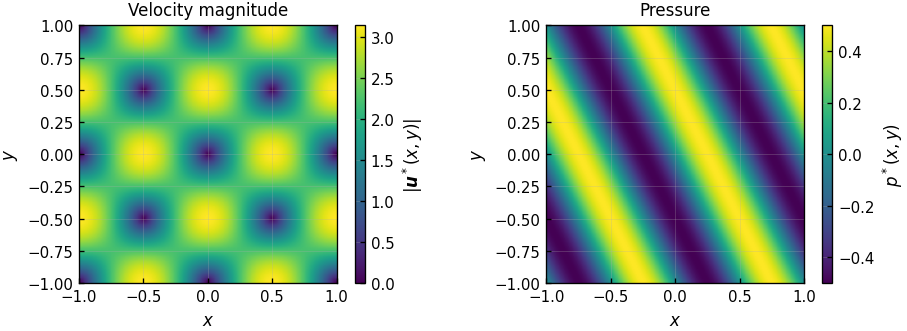

In [112]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Ground-truth solution ---

_, u_true, p_true = make_eval_grid(n_eval=201)

u_mag = (
    torch.linalg.norm(u_true, dim=1)
    .reshape(201, 201)
    .detach()
    .cpu()
    .numpy()
)

p_true = (
    p_true
    .reshape(201, 201)
    .detach()
    .cpu()
    .numpy()
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(7.0, 3.2),
    constrained_layout=True,
)

fig.get_layout_engine().set(wspace=0.25)

im0 = axes[0].imshow(
    u_mag.T,
    extent=[-1, 1, -1, 1],
    origin="lower",
    aspect="equal",
)
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].set_title("Velocity magnitude")

divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes("right", size="4%", pad=0.15)
fig.colorbar(im0, cax=cax0, label=r"$|\boldsymbol{u}^*(x,y)|$")

im1 = axes[1].imshow(
    p_true.T,
    extent=[-1, 1, -1, 1],
    origin="lower",
    aspect="equal",
)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")
axes[1].set_title("Pressure")

divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes("right", size="4%", pad=0.15)
fig.colorbar(im1, cax=cax1, label=r"$p^*(x,y)$")

fig.savefig(
    RESULT_DIR / "ground_truth.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()


## Balancing methods

Only the **MSE** loss is combined with the three balancing schemes. SINOS and D-SINOS are kept as their own residual geometries.

### Inverse-Dirichlet weighting

For the momentum, incompressibility, and boundary losses, we compute the standard deviation of the back-propagated gradients with respect to the trainable linear-layer parameters. The momentum weight is fixed to one, while the remaining weights are estimated relative to the momentum gradient scale,

$$
\widehat{\lambda}_k
=
\frac{
\sigma_{\mathrm{mom}}
}{
\sigma_k
},
\qquad
k\in\{\mathrm{div},\mathrm{BC}\}.
$$

The auxiliary weights are updated using an exponential moving average,

$$
\lambda_k
\leftarrow
(1-\eta)\lambda_k
+
\eta\,\widehat{\lambda}_k,
$$

with all weights initialized to one and $\eta=0.5$.

### GradNorm

For losses $L_i$ with adaptive weights $w_i$, GradNorm measures

$$
G_i
=
\left\|
\nabla_W (w_i L_i)
\right\|_2
$$

with respect to the last shared hidden layer $W$. These are compared with targets

$$
\overline{G}\,r_i^\alpha,
$$

where $r_i$ is the relative inverse training rate. The weights are updated by minimizing the corresponding $L^1$ objective and renormalized such that

$$
\sum_i w_i = 3.
$$

We use $\alpha=1.5$.

### NTK balancing

For each residual vector $r_i$, let

$$
J_i
=
\frac{\partial r_i}{\partial\theta}.
$$

The mean NTK trace per residual component is estimated with normalized Hutchinson probes,

$$
\tau_i
=
\frac{1}{n_i}\operatorname{Tr}(J_iJ_i^\top)
=
\mathbb E_z\!\left[\|J_i^\top z\|_2^2\right],
\qquad
z_k\in\left\{-\frac{1}{\sqrt{n_i}},+\frac{1}{\sqrt{n_i}}\right\}.
$$

The weights are proportional to the inverse traces and normalized to sum to three,

$$
\lambda_i
=
3\,
\frac{\tau_i^{-1}}
     {\sum_j \tau_j^{-1}}.
$$


In [97]:
# --- Helper functions for balancing methods ---

EPS = 1e-30


def _all_trainable_parameters(model):
    return tuple(p for p in model.parameters() if p.requires_grad)


def _linear_parameters(model):
    params = []
    for module in model.modules():
        if isinstance(module, nn.Linear):
            params.extend(p for p in module.parameters() if p.requires_grad)
    return tuple(params) if params else _all_trainable_parameters(model)


def _last_shared_parameters(model):
    linears = [module for module in model.modules() if isinstance(module, nn.Linear)]

    if len(linears) >= 2:
        return tuple(p for p in linears[-2].parameters() if p.requires_grad)

    if linears:
        return tuple(p for p in linears[-1].parameters() if p.requires_grad)

    params = _all_trainable_parameters(model)
    return params[-2:] if len(params) >= 2 else params


def _grad_std(loss, params):
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )

    n = 0
    s1 = loss.new_zeros(())
    s2 = loss.new_zeros(())

    for g in grads:
        if g is None:
            continue
        gd = g.detach()
        n += gd.numel()
        s1 = s1 + gd.sum()
        s2 = s2 + gd.square().sum()

    if n <= 1:
        return loss.new_zeros(())

    mean = s1 / n
    var = (s2 - n * mean.square()) / (n - 1)
    return torch.sqrt(torch.clamp(var, min=0.0))


def _grad_l2_norm(loss, params):
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )
    sq = loss.new_zeros(())
    for g in grads:
        if g is not None:
            sq = sq + g.detach().square().sum()
    return torch.sqrt(sq + EPS)


def _hutchinson_ntk_trace_per_output(residual, params, generator, n_probes=1):
    r = residual.reshape(-1)
    n = r.numel()
    estimate = r.new_zeros(())

    for _ in range(n_probes):
        z = torch.randint(
            0,
            2,
            (n,),
            generator=generator,
            device=r.device,
            dtype=torch.int64,
        ).to(r.dtype)
        z = (2.0 * z - 1.0) / np.sqrt(n)

        vjp = torch.autograd.grad(
            r,
            params,
            grad_outputs=z,
            retain_graph=True,
            create_graph=False,
            allow_unused=True,
        )

        sq = r.new_zeros(())
        for g in vjp:
            if g is not None:
                sq = sq + g.detach().square().sum()
        estimate = estimate + sq

    return estimate / n_probes


In [98]:
# --- Update rules for balancing methods ---

def update_inverse_dirichlet(model, mom_loss, div_loss, bc_loss, state):
    params = _linear_parameters(model)

    std_mom = _grad_std(mom_loss, params)
    std_div = _grad_std(div_loss, params)
    std_bc = _grad_std(bc_loss, params)

    lambda_hat = torch.stack((
        std_mom / (std_div + EPS),
        std_mom / (std_bc + EPS),
    ))

    old = state["weights"][1:]
    new = (1.0 - ID_EMA_NEW) * old + ID_EMA_NEW * lambda_hat

    state["weights"] = torch.cat((
        new.new_ones(1),
        new.detach(),
    ))


def update_gradnorm(model, mom_loss, div_loss, bc_loss, state):
    selected_params = _last_shared_parameters(model)

    losses = (mom_loss, div_loss, bc_loss)

    base_norms = torch.stack([
        _grad_l2_norm(loss, selected_params)
        for loss in losses
    ]).detach()

    losses_detached = torch.stack([
        loss.detach()
        for loss in losses
    ])

    if state["initial_losses"] is None:
        state["initial_losses"] = losses_detached.clamp_min(EPS)

    w = state["weight_param"]
    actual = w * base_norms

    loss_ratio = losses_detached / state["initial_losses"]
    relative_rate = loss_ratio / loss_ratio.mean().clamp_min(EPS)
    target = (
        actual.mean().detach()
        * relative_rate.pow(GRADNORM_ALPHA)
    ).detach()

    gradnorm_objective = torch.abs(actual - target).sum()
    grad_w = torch.autograd.grad(
        gradnorm_objective,
        w,
        retain_graph=False,
    )[0]

    opt_w = state["weight_optimizer"]
    opt_w.zero_grad(set_to_none=True)
    w.grad = grad_w
    opt_w.step()

    with torch.no_grad():
        w.clamp_(min=1e-12)
        w.mul_(3.0 / w.sum().clamp_min(EPS))
        state["weights"] = w.detach().clone()


def update_ntk(model, r_mom, r_div, r_bc, state):
    params = _all_trainable_parameters(model)

    traces = torch.stack((
        _hutchinson_ntk_trace_per_output(
            r_mom,
            params,
            state["rng"],
            n_probes=NTK_PROBES,
        ),
        _hutchinson_ntk_trace_per_output(
            r_div,
            params,
            state["rng"],
            n_probes=NTK_PROBES,
        ),
        _hutchinson_ntk_trace_per_output(
            r_bc,
            params,
            state["rng"],
            n_probes=NTK_PROBES,
        ),
    )).clamp_min(EPS)

    inv = traces.reciprocal()
    raw = 3.0 * inv / inv.sum()

    old = state["weights"]
    smoothed = NTK_EMA_OLD * old + (1.0 - NTK_EMA_OLD) * raw
    state["weights"] = (3.0 * smoothed / smoothed.sum()).detach()


## Training


In [99]:
# Common optimization budget
MAX_CLOSURE_CALLS = 30_000
EVAL_N = 201

# L-BFGS optimizer
LBFGS_LR = 1.0
LBFGS_HISTORY = 50
LBFGS_MAX_EVAL = 20
LBFGS_TOL_GRAD = 1e-10
LBFGS_TOL_CHANGE = 1e-12

# Inverse-Dirichlet
ID_EMA_NEW = 0.5
ID_UPDATE_EVERY = 5

# GradNorm
GRADNORM_ALPHA = 1.5
GRADNORM_WEIGHT_LR = 0.025
GRADNORM_UPDATE_EVERY = 1

# NTK balancing
NTK_UPDATE_EVERY = 10
NTK_PROBES = 1
NTK_EMA_OLD = 0.0

RUN_CONFIGS = [
    {"method": "MSE", "loss_kind": "mse", "balancer": None, "balance_every": None},
    {"method": "ID", "loss_kind": "mse", "balancer": "inverse_dirichlet", "balance_every": ID_UPDATE_EVERY},
    {"method": "GradNorm", "loss_kind": "mse", "balancer": "gradnorm", "balance_every": GRADNORM_UPDATE_EVERY},
    {"method": "NTK", "loss_kind": "mse", "balancer": "ntk", "balance_every": NTK_UPDATE_EVERY},
    {"method": "SINOS", "loss_kind": "sinos", "balancer": None, "balance_every": None},
    {"method": "D-SINOS", "loss_kind": "dsinos", "balancer": None, "balance_every": None},
]


def should_record_closure_call(k):
    if k == 0:
        return True
    if k <= 100:
        return True

    decade = 10 ** int(np.floor(np.log10(k)))
    stride = max(1, decade // 10)
    return (k % stride) == 0


print("training runs:", N_REPS * len(RUN_CONFIGS))
print("total closure-call target:", MAX_CLOSURE_CALLS)
print("evaluation grid:", f"{EVAL_N} x {EVAL_N}")
print("execution: one repetition; formulations in parallel")
print("method workers:", N_METHOD_WORKERS, "| threads per worker:", THREADS_PER_WORKER)


training runs: 6
total closure-call target: 30000
evaluation grid: 201 x 201
execution: one repetition; formulations in parallel
method workers: 2 | threads per worker: 6


In [100]:
def _diagnostic_grid(n_eval):
    return make_eval_grid(n_eval=n_eval)


def _diagnostic_metrics(model, XY, u_true, p_true):
    with torch.no_grad():
        pred = model(XY)
        u_pred = pred[:, 0:2]
        p_pred = pred[:, 2:3]
        p_pred = p_pred - torch.mean(p_pred) + torch.mean(p_true)

        u_error = u_true - u_pred
        p_error = p_true - p_pred

        u_point_error = torch.linalg.norm(u_error, dim=1)
        p_abs_error = torch.abs(p_error.reshape(-1))

        u_mse = torch.mean(u_point_error.square())
        p_mse = torch.mean(p_error.square())

        combined = torch.sqrt(
            u_point_error.square() + p_error.reshape(-1).square()
        )
        solution_mse = torch.mean(combined.square())

        return {
            "u_mse": float(u_mse),
            "u_rmse": float(torch.sqrt(u_mse)),
            "u_max_error": float(torch.max(u_point_error)),
            "p_mse": float(p_mse),
            "p_rmse": float(torch.sqrt(p_mse)),
            "p_max_error": float(torch.max(p_abs_error)),
            "solution_mse": float(solution_mse),
            "solution_rmse": float(torch.sqrt(solution_mse)),
            "solution_max_error": float(torch.max(combined)),
        }


def _init_balancer(model, config, seed):
    state = {
        "weights": torch.ones(3, dtype=torch.float64, device="cpu"),
        "initial_losses": None,
        "rng": torch.Generator(device="cpu").manual_seed(seed),
    }

    if config["balancer"] == "gradnorm":
        weight_param = nn.Parameter(torch.ones(3, dtype=torch.float64, device="cpu"))
        state["weight_param"] = weight_param
        state["weight_optimizer"] = torch.optim.Adam(
            [weight_param],
            lr=GRADNORM_WEIGHT_LR,
        )

    return state


def _update_balancer(
    model,
    config,
    state,
    r_mom,
    r_div,
    r_bc,
    mom_loss,
    div_loss,
    bc_loss,
):
    balancer = config["balancer"]

    if balancer is None:
        return

    if balancer == "inverse_dirichlet":
        update_inverse_dirichlet(
            model,
            mom_loss,
            div_loss,
            bc_loss,
            state,
        )
        return

    if balancer == "gradnorm":
        update_gradnorm(
            model,
            mom_loss,
            div_loss,
            bc_loss,
            state,
        )
        return

    if balancer == "ntk":
        update_ntk(
            model,
            r_mom,
            r_div,
            r_bc,
            state,
        )
        return

    raise ValueError(f"unknown balancer={balancer!r}")


In [101]:
def _warm_state_slug(method):
    return method.lower().replace("+", "plus").replace("-", "_").replace(" ", "_")


def warm_state_path(seed, method):
    return WARM_START_DIR / f"seed_{seed}__{_warm_state_slug(method)}.pt"


def load_warm_state(seed, method):
    path = warm_state_path(seed, method)
    if not path.exists():
        raise FileNotFoundError(f"Missing warm-start state: {path}")

    saved = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    if int(saved["seed"]) != int(seed):
        raise ValueError(f"Seed mismatch in {path}: {saved['seed']} != {seed}")
    if saved["method"] != method:
        raise ValueError(
            f"Method mismatch in {path}: {saved['method']!r} != {method!r}"
        )

    return saved


def _restore_posthoc_balancer(model, config, seed, saved):
    state = _init_balancer(model, config, seed + 100_000)

    saved_weights = torch.tensor(
        saved["final_weights"],
        dtype=dtype,
        device=device,
    )
    state["weights"] = saved_weights.clone()

    if config["balancer"] == "gradnorm":
        with torch.no_grad():
            state["weight_param"].copy_(saved_weights)

        records = saved.get("history_records", [])
        if records:
            initial_row = min(records, key=lambda row: row["closure_call"])
            state["initial_losses"] = torch.tensor(
                [
                    float(initial_row["mom_loss"]),
                    float(initial_row["div_loss"]),
                    float(initial_row["bc_loss"]),
                ],
                dtype=dtype,
                device=device,
            ).clamp_min(EPS)

    return state


def _save_same_warm_start_format(item):
    path = warm_state_path(item["seed"], item["method"])
    tmp_path = path.with_suffix(path.suffix + ".tmp")

    payload = {
        "format": "posthoc_warm_start_v1",
        "seed": int(item["seed"]),
        "rep": int(item["rep"]),
        "method": item["method"],
        "config": copy.deepcopy(item["config"]),
        "state_dict": {
            key: value.detach().cpu().clone()
            for key, value in item["state_dict"].items()
        },
        "closure_calls": int(item["closure_calls"]),
        "steps": int(item["steps"]),
        "elapsed_s": float(item["elapsed_s"]),
        "final_weights": tuple(float(x) for x in item["final_weights"]),
        "final_losses": copy.deepcopy(item["final_losses"]),
        "history_records": item["history"].to_dict(orient="records"),
    }

    torch.save(payload, tmp_path)
    os.replace(tmp_path, path)


PRINT_CALLS = {1} | {round(k * MAX_CLOSURE_CALLS / 10) for k in range(1, 11)}


def run_one_method(config, base_state, data, seed, rep, saved=None):
    model = make_model(initialize=False)

    if saved is None:
        if base_state is None:
            raise ValueError("Fresh mode requires base_state.")

        model.load_state_dict(copy.deepcopy(base_state))

        history = []
        closure_calls = 0
        outer_steps = 0
        elapsed_offset = 0.0
        balance_state = _init_balancer(model, config, seed + 100_000)

    else:
        model.load_state_dict(saved["state_dict"])

        history = copy.deepcopy(saved.get("history_records", []))
        closure_calls = int(saved["closure_calls"])
        outer_steps = int(saved["steps"])
        elapsed_offset = float(saved.get("elapsed_s", 0.0))
        balance_state = _restore_posthoc_balancer(
            model,
            config,
            seed,
            saved,
        )

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=LBFGS_LR,
        max_iter=1,
        max_eval=LBFGS_MAX_EVAL,
        history_size=LBFGS_HISTORY,
        line_search_fn="strong_wolfe",
        tolerance_grad=LBFGS_TOL_GRAD,
        tolerance_change=LBFGS_TOL_CHANGE,
    )

    eval_X, eval_u_true, eval_p_true = _diagnostic_grid(EVAL_N)

    start = time.perf_counter()
    step_context = {
        "step": outer_steps,
        "balance_updated": False,
    }

    def elapsed_total():
        return elapsed_offset + (time.perf_counter() - start)

    def append_history_row(
        total_loss,
        mom_loss,
        div_loss,
        bc_loss,
        gauge_loss,
    ):
        metrics = _diagnostic_metrics(
            model,
            eval_X,
            eval_u_true,
            eval_p_true,
        )
        weights = balance_state["weights"].detach()

        row = {
            "rep": rep,
            "seed": seed,
            "method": config["method"],
            "step": outer_steps,
            "closure_call": closure_calls,
            "total_loss": float(total_loss.detach()),
            "mom_loss": float(mom_loss.detach()),
            "div_loss": float(div_loss.detach()),
            "bc_loss": float(bc_loss.detach()),
            "gauge_loss": float(gauge_loss.detach()),
            "mom_weight": float(weights[0]),
            "div_weight": float(weights[1]),
            "bc_weight": float(weights[2]),
            **metrics,
            "elapsed_s": elapsed_total(),
        }
        history.append(row)

        if closure_calls in PRINT_CALLS:
            print(
                f"rep {rep+1:02d}/{N_REPS} | {config['method']:16s} | "
                f"closure {closure_calls:06d}/{MAX_CLOSURE_CALLS} | "
                f"rmse {row['solution_rmse']:.3e} | "
                f"max {row['solution_max_error']:.3e}"
            )

    if saved is None:
        (
            r_mom0,
            r_div0,
            r_bc0,
            mom0,
            div0,
            bc0,
            gauge0,
        ) = compute_loss_components(
            model,
            data,
            config["loss_kind"],
        )
        weights0 = balance_state["weights"].detach()
        total0 = (
            weights0[0] * mom0
            + weights0[1] * div0
            + weights0[2] * bc0
            + gauge0
        )
        append_history_row(total0, mom0, div0, bc0, gauge0)
        del r_mom0, r_div0, r_bc0, mom0, div0, bc0, gauge0, total0

    def closure():
        nonlocal closure_calls
        closure_calls += 1
        optimizer.zero_grad(set_to_none=True)

        (
            r_mom,
            r_div,
            r_bc,
            mom_loss,
            div_loss,
            bc_loss,
            gauge_loss,
        ) = compute_loss_components(
            model,
            data,
            config["loss_kind"],
        )

        if (
            config["balancer"] is not None
            and step_context["step"] % config["balance_every"] == 0
            and not step_context["balance_updated"]
        ):
            _update_balancer(
                model,
                config,
                balance_state,
                r_mom,
                r_div,
                r_bc,
                mom_loss,
                div_loss,
                bc_loss,
            )
            step_context["balance_updated"] = True

        weights = balance_state["weights"].detach()
        total_loss = (
            weights[0] * mom_loss
            + weights[1] * div_loss
            + weights[2] * bc_loss
            + gauge_loss
        )
        total_loss.backward()

        if closure_calls <= MAX_CLOSURE_CALLS and should_record_closure_call(
            closure_calls
        ):
            append_history_row(
                total_loss,
                mom_loss,
                div_loss,
                bc_loss,
                gauge_loss,
            )

        return total_loss

    if closure_calls >= MAX_CLOSURE_CALLS:
        print(
            f"seed {seed} | {config['method']}: already at "
            f"{closure_calls} closure calls >= target {MAX_CLOSURE_CALLS}."
        )
    else:
        while closure_calls < MAX_CLOSURE_CALLS:
            step_context["step"] = outer_steps
            step_context["balance_updated"] = False
            optimizer.step(closure)
            outer_steps += 1

    elapsed_s = elapsed_total()

    (
        _,
        _,
        _,
        mom_final,
        div_final,
        bc_final,
        gauge_final,
    ) = compute_loss_components(
        model,
        data,
        config["loss_kind"],
    )

    weights_final = balance_state["weights"].detach()
    total_final = (
        weights_final[0] * mom_final
        + weights_final[1] * div_final
        + weights_final[2] * bc_final
        + gauge_final
    )

    result = {
        "rep": rep,
        "seed": seed,
        "method": config["method"],
        "config": config,
        "state_dict": {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        },
        "history": pd.DataFrame(history),
        "elapsed_s": elapsed_s,
        "steps": outer_steps,
        "closure_calls": closure_calls,
        "closure_budget": MAX_CLOSURE_CALLS,
        "closure_overshoot": closure_calls - MAX_CLOSURE_CALLS,
        "final_weights": tuple(float(x) for x in balance_state["weights"]),
        "final_losses": {
            "total_loss": float(total_final.detach()),
            "mom_loss": float(mom_final.detach()),
            "div_loss": float(div_final.detach()),
            "bc_loss": float(bc_final.detach()),
            "gauge_loss": float(gauge_final.detach()),
        },
    }

    _save_same_warm_start_format(result)

    return result


In [102]:
def run_one_method_worker(config, base_state, data, rep_seed, rep):
    torch.set_num_threads(THREADS_PER_WORKER)
    np.random.seed(rep_seed)
    torch.manual_seed(rep_seed)

    saved = None

    if MODE == "resume":
        path = warm_state_path(rep_seed, config["method"])

        if path.exists():
            saved = load_warm_state(
                rep_seed,
                config["method"],
            )
            print(
                f"rep {rep + 1:02d}/{N_REPS} | "
                f"{config['method']:16s} | loading saved state "
                f"at closure {saved['closure_calls']}"
            )
        else:
            print(
                f"rep {rep + 1:02d}/{N_REPS} | "
                f"{config['method']:16s} | no saved state -> starting fresh"
            )

    return run_one_method(
        config=config,
        base_state=base_state,
        data=data,
        seed=rep_seed,
        rep=rep,
        saved=saved,
    )


def run_one_repetition(rep, rep_seed):
    np.random.seed(rep_seed)
    torch.manual_seed(rep_seed)

    base_model = make_model(initialize=True)
    base_state = copy.deepcopy(base_model.state_dict())
    del base_model

    print("=" * 80)
    print(
        f"{MODE.upper()} {rep + 1:02d}/{N_REPS} | seed = {rep_seed}"
    )
    print("=" * 80)

    with parallel_config(
        backend="loky",
        n_jobs=N_METHOD_WORKERS,
        inner_max_num_threads=THREADS_PER_WORKER,
    ):
        rep_results = Parallel()(
            delayed(run_one_method_worker)(
                config,
                base_state,
                DATA,
                rep_seed,
                rep,
            )
            for config in RUN_CONFIGS
        )

    return rep_results


print("MODE:", MODE)
print(
    f"Running {N_REPS} repetition × {len(RUN_CONFIGS)} formulations "
    f"= {N_REPS * len(RUN_CONFIGS)} runs"
)
print("Seeds:", REP_SEEDS)
print("Warm-state directory:", WARM_START_DIR)
print("Total closure target:", MAX_CLOSURE_CALLS)
print(
    f"Parallelization: {N_METHOD_WORKERS} method workers; "
    f"{THREADS_PER_WORKER} CPU threads per worker."
)
print("Methods are executed in parallel in batches of up to three.\n")

nested_results = [
    run_one_repetition(rep, rep_seed)
    for rep, rep_seed in enumerate(REP_SEEDS)
]

all_results = [
    item
    for rep_results in nested_results
    for item in rep_results
]

results = {
    (item["rep"], item["method"]): item
    for item in all_results
}

hist = pd.concat(
    [item["history"] for item in all_results],
    ignore_index=True,
)
hist = hist.sort_values(
    ["rep", "method", "closure_call"]
).reset_index(drop=True)

hist.to_csv(
    RESULT_DIR / "history_all_seeds.csv",
    index=False,
)

manifest = {
    "format": "posthoc_warm_start_manifest_v1",
    "N_REPS": int(N_REPS),
    "REP_SEEDS": [int(seed) for seed in REP_SEEDS],
    "methods": [config["method"] for config in RUN_CONFIGS],
    "saved_files": [
        warm_state_path(item["seed"], item["method"]).name
        for item in all_results
    ],
    "note": (
        f"States saved after MODE={MODE!r}. "
        "The warm_start_states format does not contain L-BFGS optimizer memory."
    ),
}

manifest_path = WARM_START_DIR / "manifest.pt"
tmp_manifest = manifest_path.with_suffix(".pt.tmp")
torch.save(manifest, tmp_manifest)
os.replace(tmp_manifest, manifest_path)

print("\nFinished.")
print("Updated warm-start states:")
print(WARM_START_DIR)


MODE: resume
Running 1 repetition × 6 formulations = 6 runs
Seeds: [1234]
Warm-state directory: results/navier_stokes_pinn_balancing/warm_start_states
Total closure target: 30000
Parallelization: 2 method workers; 6 CPU threads per worker.
Methods are executed in parallel in batches of up to three.

RESUME 01/1 | seed = 1234
rep 01/1 | MSE              | loading saved state at closure 30000
rep 01/1 | ID               | loading saved state at closure 30001
seed 1234 | ID: already at 30001 closure calls >= target 30000.
seed 1234 | MSE: already at 30000 closure calls >= target 30000.
rep 01/1 | GradNorm         | loading saved state at closure 30000
seed 1234 | GradNorm: already at 30000 closure calls >= target 30000.
rep 01/1 | NTK              | loading saved state at closure 25001
rep 01/1 | SINOS            | loading saved state at closure 25001
rep 01/1 | SINOS            | closure 027000/30000 | rmse 6.282e-03 | max 1.874e-02
rep 01/1 | NTK              | closure 027000/30000 | rm

/Users/philhofmann/miniconda3/envs/D-SINOS/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


rep 01/1 | D-SINOS          | loading saved state at closure 25001
rep 01/1 | NTK              | closure 030000/30000 | rmse 3.137e-03 | max 9.662e-03
rep 01/1 | D-SINOS          | closure 027000/30000 | rmse 1.371e-02 | max 6.985e-02
rep 01/1 | D-SINOS          | closure 030000/30000 | rmse 1.111e-02 | max 6.418e-02

Finished.
Updated warm-start states:
results/navier_stokes_pinn_balancing/warm_start_states


In [103]:
# --- Final error statistics across repetitions ---

method_order = [config["method"] for config in RUN_CONFIGS]

final_error_records = []

for item in all_results:
    rep = item["rep"]
    method = item["method"]

    model = make_model(initialize=False)
    model.load_state_dict(item["state_dict"])
    model.eval()

    evaluation = evaluate_solution(model, n_eval=201)

    final_error_records.append({
        "rep": rep,
        "method": method,
        "u_rmse": evaluation["u_rmse"],
        "u_max_error": evaluation["u_max_error"],
        "p_rmse": evaluation["p_rmse"],
        "p_max_error": evaluation["p_max_error"],
        "solution_rmse": evaluation["solution_rmse"],
        "solution_max_error": evaluation["solution_max_error"],
    })

    del model

final_errors = pd.DataFrame(final_error_records)

summary_error = (
    final_errors
    .groupby("method", observed=True)
    .agg(
        **{
            "Velocity RMSE (mean)": ("u_rmse", "mean"),
            "Velocity RMSE (std)": ("u_rmse", "std"),
            "Velocity max. error (mean)": ("u_max_error", "mean"),
            "Velocity max. error (std)": ("u_max_error", "std"),
            "Pressure RMSE (mean)": ("p_rmse", "mean"),
            "Pressure RMSE (std)": ("p_rmse", "std"),
            "Pressure max. error (mean)": ("p_max_error", "mean"),
            "Pressure max. error (std)": ("p_max_error", "std"),
            "Combined RMSE (mean)": ("solution_rmse", "mean"),
            "Combined RMSE (std)": ("solution_rmse", "std"),
            "Combined max. error (mean)": ("solution_max_error", "mean"),
            "Combined max. error (std)": ("solution_max_error", "std"),
        }
    )
    .reindex(method_order)
)

summary_error.to_csv(
    RESULT_DIR / f"summary_error_{N_REPS}reps.csv"
)

print(f"Final error statistics over {N_REPS} repetitions:")
display(summary_error.style.format("{:.3e}"))


Final error statistics over 1 repetitions:


,Velocity RMSE (mean),Velocity RMSE (std),Velocity max. error (mean),Velocity max. error (std),Pressure RMSE (mean),Pressure RMSE (std),Pressure max. error (mean),Pressure max. error (std),Combined RMSE (mean),Combined RMSE (std),Combined max. error (mean),Combined max. error (std)
method,,,,,,,,,,,,
MSE,1.080e-03,nan,3.528e-03,nan,2.522e-03,nan,1.032e-02,nan,2.744e-03,nan,1.081e-02,nan
ID,1.492e-02,nan,3.733e-02,nan,3.588e-02,nan,9.694e-02,nan,3.885e-02,nan,9.760e-02,nan
GradNorm,4.880e-02,nan,9.403e-02,nan,1.774e-01,nan,3.724e-01,nan,1.840e-01,nan,3.732e-01,nan
NTK,1.154e-03,nan,3.221e-03,nan,2.911e-03,nan,9.525e-03,nan,3.131e-03,nan,9.647e-03,nan
SINOS,2.362e-03,nan,5.296e-03,nan,5.775e-03,nan,1.789e-02,nan,6.239e-03,nan,1.790e-02,nan
D-SINOS,4.671e-03,nan,1.157e-02,nan,1.009e-02,nan,6.427e-02,nan,1.112e-02,nan,6.427e-02,nan


In [104]:
# --- Plotting ---

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


In [105]:
# --- Evaluate final models ---

evaluations = {}

for item in all_results:
    rep = item["rep"]
    method = item["method"]

    model = make_model(initialize=False)
    model.load_state_dict(item["state_dict"])
    model.eval()

    evaluations[(rep, method)] = evaluate_solution(
        model,
        n_eval=201,
    )

    del model


In [106]:
# --- Select best repetition by minimum maximum error ---

best_reps = {}

for method in method_order:
    best_rep = min(
        range(N_REPS),
        key=lambda rep: evaluations[(rep, method)]["solution_max_error"],
    )

    best_reps[method] = best_rep

    print(
        f"{method}: rep {best_rep}, "
        f"max. error = {evaluations[(best_rep, method)]['solution_max_error']:.3e}"
    )


MSE: rep 0, max. error = 1.081e-02
ID: rep 0, max. error = 9.760e-02
GradNorm: rep 0, max. error = 3.732e-01
NTK: rep 0, max. error = 9.647e-03
SINOS: rep 0, max. error = 1.790e-02
D-SINOS: rep 0, max. error = 6.427e-02


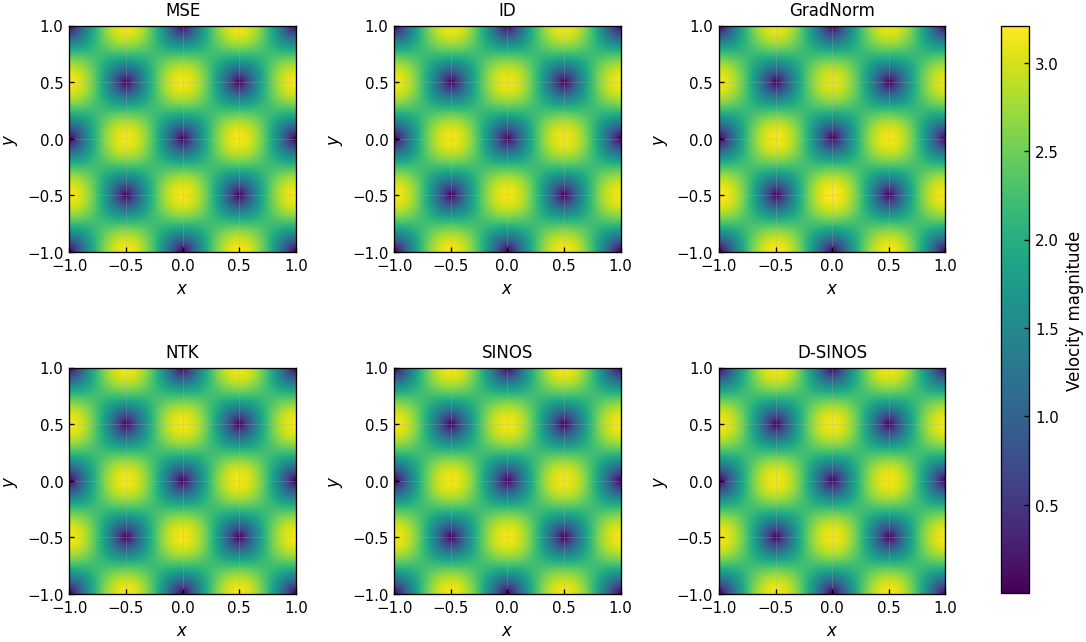

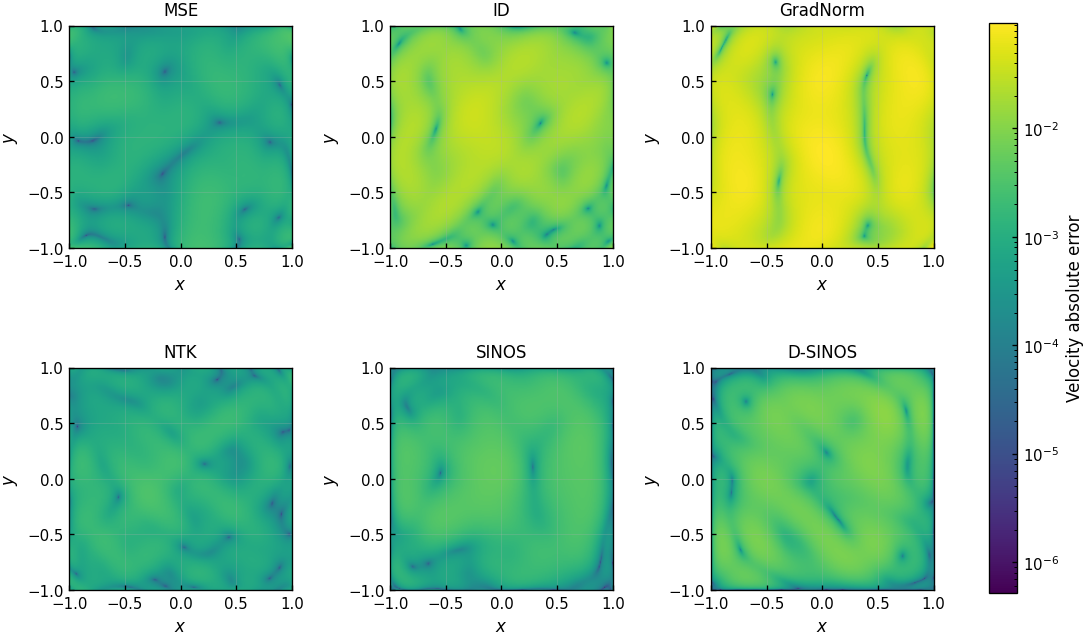

In [107]:
# --- Velocity prediction and absolute error plots ---

eps = 1e-14

velocity_predictions = {}
velocity_errors = {}

for method in method_order:
    result = evaluations[(best_reps[method], method)]
    n_eval = result["n_eval"]

    velocity_predictions[method] = np.linalg.norm(
        result["u_prediction"],
        axis=1,
    ).reshape(n_eval, n_eval)

    velocity_errors[method] = np.linalg.norm(
        result["u_error"],
        axis=1,
    ).reshape(n_eval, n_eval)

vmin = min(arr.min() for arr in velocity_predictions.values())
vmax = max(arr.max() for arr in velocity_predictions.values())

fig, axes = plt.subplots(
    2, 3,
    figsize=(9.2, 5.7),
    constrained_layout=True,
)

im = None

for ax, method in zip(axes.flat, method_order):
    im = ax.imshow(
        velocity_predictions[method].T,
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(method)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    label="Velocity magnitude",
)

fig.savefig(
    RESULT_DIR / f"best_velocity_prediction_{N_REPS}reps.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()


positive_values = np.concatenate(
    [
        arr[arr > eps].ravel()
        for arr in velocity_errors.values()
        if np.any(arr > eps)
    ]
)

vmin = max(eps, positive_values.min()) if positive_values.size else eps
vmax = max(
    max(arr.max() for arr in velocity_errors.values()),
    10.0 * vmin,
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(9.2, 5.7),
    constrained_layout=True,
)

im = None

for ax, method in zip(axes.flat, method_order):
    im = ax.imshow(
        np.maximum(velocity_errors[method].T, eps),
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.set_title(method)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    label="Velocity absolute error",
)

fig.savefig(
    RESULT_DIR / f"best_velocity_absolute_error_{N_REPS}reps.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()


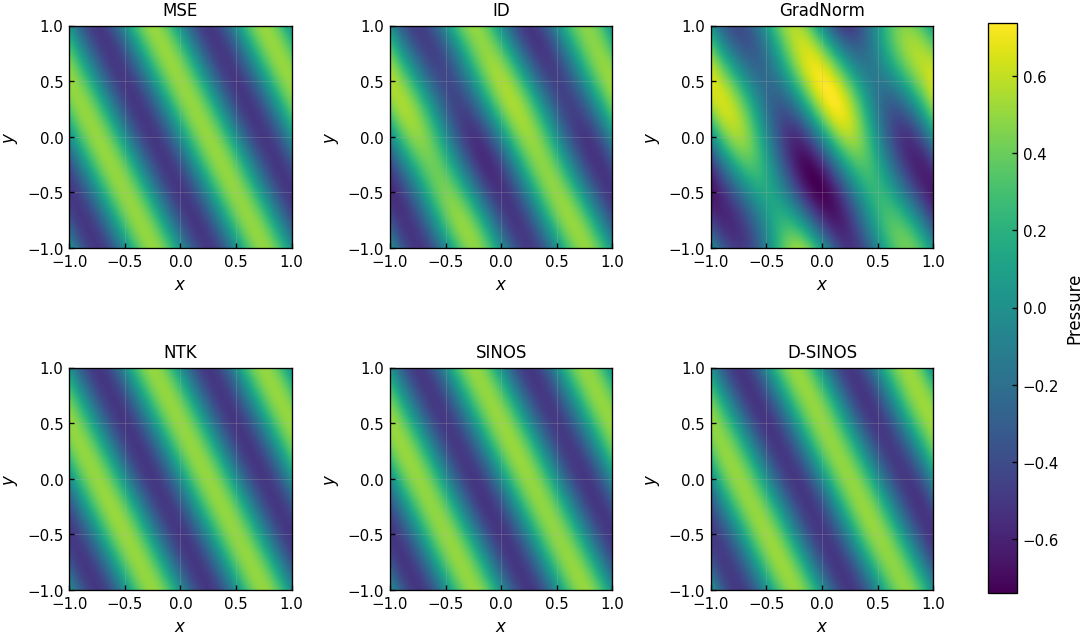

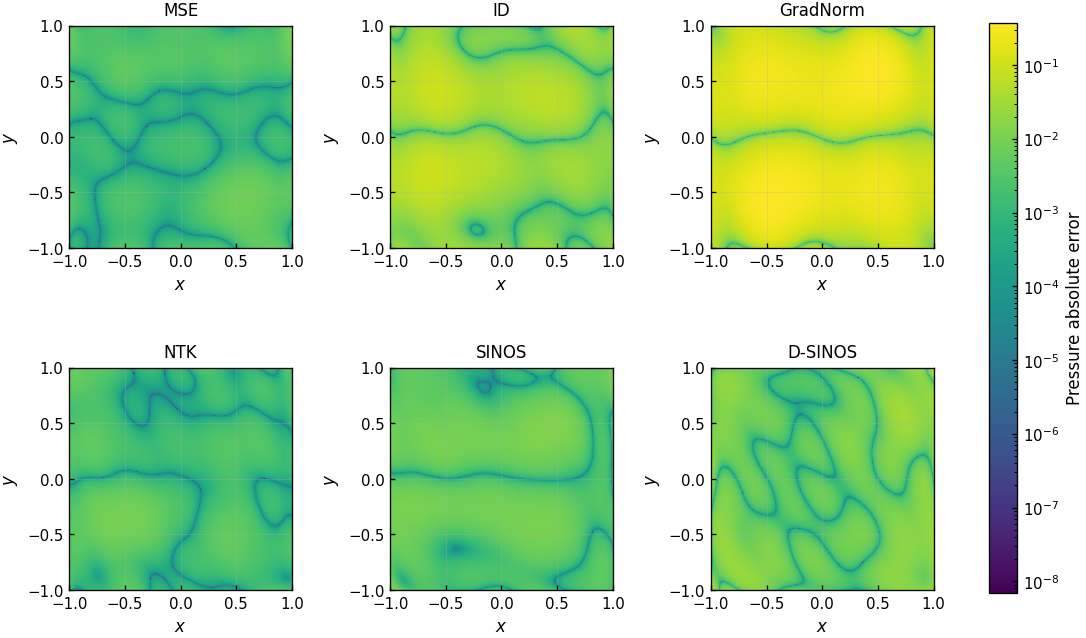

In [108]:
# --- Pressure prediction and absolute error plots ---

pressure_predictions = {}
pressure_errors = {}

for method in method_order:
    result = evaluations[(best_reps[method], method)]
    n_eval = result["n_eval"]

    pressure_predictions[method] = result["p_prediction"].reshape(n_eval, n_eval)
    pressure_errors[method] = np.abs(
        result["p_error"].reshape(n_eval, n_eval)
    )

vmin = min(arr.min() for arr in pressure_predictions.values())
vmax = max(arr.max() for arr in pressure_predictions.values())

fig, axes = plt.subplots(
    2, 3,
    figsize=(9.2, 5.7),
    constrained_layout=True,
)

im = None

for ax, method in zip(axes.flat, method_order):
    im = ax.imshow(
        pressure_predictions[method].T,
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(method)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    label="Pressure",
)

fig.savefig(
    RESULT_DIR / f"best_pressure_prediction_{N_REPS}reps.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()


positive_values = np.concatenate(
    [
        arr[arr > eps].ravel()
        for arr in pressure_errors.values()
        if np.any(arr > eps)
    ]
)

vmin = max(eps, positive_values.min()) if positive_values.size else eps
vmax = max(
    max(arr.max() for arr in pressure_errors.values()),
    10.0 * vmin,
)

fig, axes = plt.subplots(
    2, 3,
    figsize=(9.2, 5.7),
    constrained_layout=True,
)

im = None

for ax, method in zip(axes.flat, method_order):
    im = ax.imshow(
        np.maximum(pressure_errors[method].T, eps),
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.set_title(method)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    label="Pressure absolute error",
)

fig.savefig(
    RESULT_DIR / f"best_pressure_absolute_error_{N_REPS}reps.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()


In [109]:
# --- Mean history plots ---

def mean_history(metric):
    df = hist.sort_values(["method", "rep", "closure_call"]).copy()

    df[metric] = df.groupby(["method", "rep"], observed=True)[metric].cummin()

    return (
        df.groupby(["method", "closure_call"], observed=True)[metric]
        .mean()
        .reset_index()
    )


def plot_mean_history(metric, ylabel, filename):
    agg = mean_history(metric)

    fig, ax = plt.subplots(figsize=(4, 3))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, method in enumerate(method_order):
        df = agg[agg["method"] == method].sort_values("closure_call")
        color = colors[i % len(colors)]

        ax.plot(
            df["closure_call"],
            df[metric],
            color=color,
            linestyle="-",
            label=method,
        )

    ax.set_xscale("symlog", linthresh=1.0, linscale=0.5)
    ax.set_yscale("log")
    ax.set_xlim(left=0, right=MAX_CLOSURE_CALLS)

    ax.set_xlabel("L-BFGS closure call")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(
        ncol=1,
        frameon=True,
        handlelength=1.8,
        columnspacing=0.8,
        labelspacing=0.3,
    )

    plt.tight_layout()
    fig.savefig(
        RESULT_DIR / filename,
        format="pdf",
        bbox_inches="tight",
        dpi=600,
    )
    plt.show()


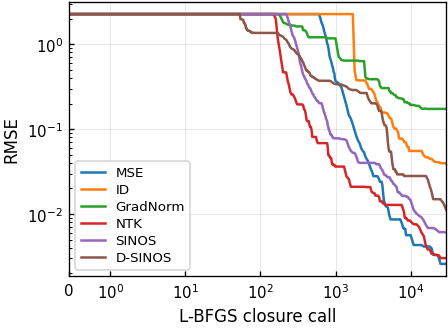

In [110]:
# --- Plot mean RMSE history ---

plot_mean_history(
    "solution_rmse",
    "RMSE",
    f"rmse_history_mean_{N_REPS}reps.pdf",
)


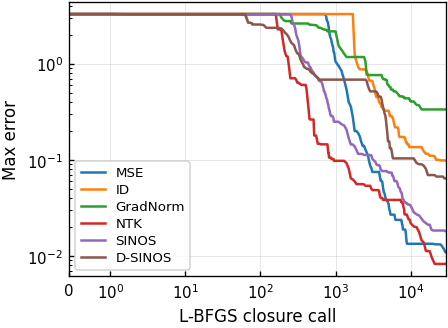

In [111]:
# --- Plot mean maximum error history ---

plot_mean_history(
    "solution_max_error",
    "Max error",
    f"max_error_history_mean_{N_REPS}reps.pdf",
)


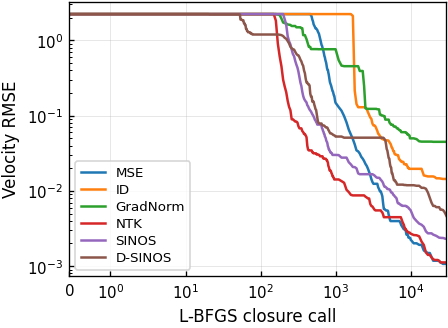

In [113]:
# --- Plot mean velocity RMSE history ---

plot_mean_history(
    "u_rmse",
    "Velocity RMSE",
    f"velocity_rmse_history_mean_{N_REPS}reps.pdf",
)

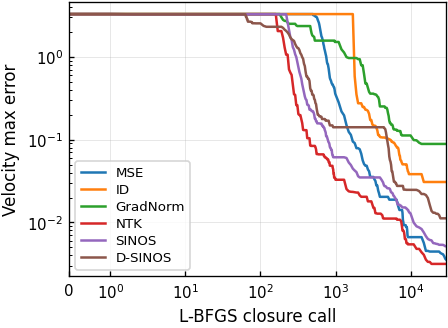

In [114]:
# --- Plot mean velocity maximum-error history ---

plot_mean_history(
    "u_max_error",
    "Velocity max error",
    f"velocity_max_error_history_mean_{N_REPS}reps.pdf",
)

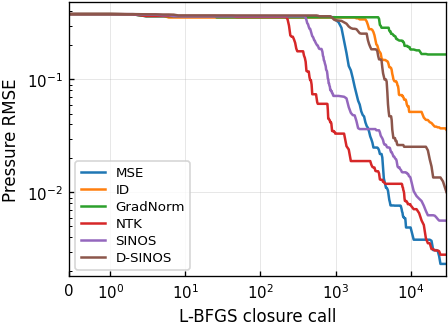

In [115]:
# --- Plot mean pressure RMSE history ---

plot_mean_history(
    "p_rmse",
    "Pressure RMSE",
    f"pressure_rmse_history_mean_{N_REPS}reps.pdf",
)

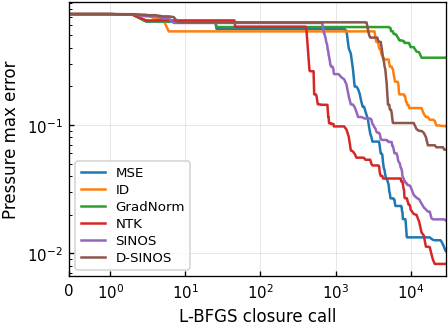

In [116]:
# --- Plot mean pressure maximum-error history ---

plot_mean_history(
    "p_max_error",
    "Pressure max error",
    f"pressure_max_error_history_mean_{N_REPS}reps.pdf",
)